In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# 🌿 Plant Disease Classification - Data Preprocessing

## Objective

The objective of this notebook is to prepare the PlantVillage dataset for training.

### Tasks

- Load the dataset
- Create training and validation datasets
- Resize images
- Normalize pixel values
- Encode labels
- Apply data augmentation
- Handle class imbalance
- Build an efficient TensorFlow data pipeline

In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import matplotlib.pyplot as plt

In [7]:
dataset_path = "/kaggle/input/datasets/emmarex/plantdisease/PlantVillage"

In [6]:
IMAGE_SIZE = (224, 224)

BATCH_SIZE = 32

SEED = 42

Why 224?

Although your images are 256×256, 224×224 is a common input size because many CNN architectures (including many pretrained models) expect it. It also reduces computation while preserving enough detail.

In [8]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

Found 20638 files belonging to 15 classes.
Using 16511 files for training.


I0000 00:00:1782501497.928314      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782501497.934520      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 20638 files belonging to 15 classes.
Using 4127 files for validation.


happened automatically:

Labels created ✔
Images resized ✔
Data shuffled ✔
Batching ✔

In [9]:
class_names = train_dataset.class_names

print(class_names)

['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


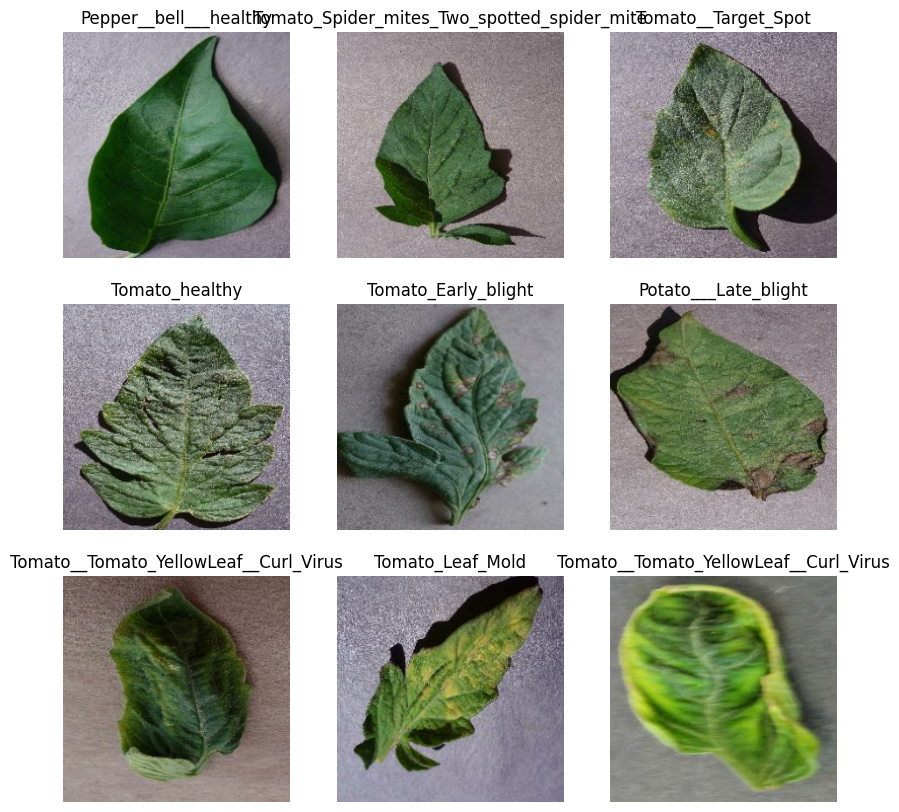

In [10]:
#Visualize a Batch - verifies that everything loaded correctly.

plt.figure(figsize=(10,10))

for images, labels in train_dataset.take(1):

    for i in range(9):

        plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

In [12]:
#Normalize - create a preprocessing layer as the first layer of our model, hence normalizationis automatic

normalization_layer = layers.Rescaling(1./255)

In [14]:
#Data Augmentation -  dataset is imbalanced, This generates slightly different versions of the images each epoch, helping the model generalize better.

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
])

In [15]:
#Optimize the Pipeline - To speed up training, lets TensorFlow prepare the next batch while the GPU is processing the current one.

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(AUTOTUNE)
val_dataset = val_dataset.prefetch(AUTOTUNE)

Class Weights

Remember the imbalance? (152 vs 3209 images) Before training, we have to compute class weights using the training labels so that errors on minority classes are penalized more. This is done just before model training to ensure the weights match the training split.

In [16]:
from sklearn.utils.class_weight import compute_class_weight

In [17]:
train_labels = []

for _, labels in train_dataset:
    train_labels.extend(labels.numpy())

train_labels = np.array(train_labels)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

#Convert them into a dictionary (TensorFlow expects this format):

class_weight_dict = {
    i: weight
    for i, weight in enumerate(class_weights)
}

print(class_weight_dict)

{0: np.float64(1.3810957758260143), 1: np.float64(0.9359977324263039), 2: np.float64(1.3572544184134814), 3: np.float64(1.3555829228243022), 4: np.float64(9.096969696969698), 5: np.float64(0.652866745749308), 6: np.float64(1.3606098063452823), 7: np.float64(0.7019982993197279), 8: np.float64(1.4351151673185572), 9: np.float64(0.7982112642011119), 10: np.float64(0.8189980158730159), 11: np.float64(0.963021289005541), 12: np.float64(0.42763532763532763), 13: np.float64(3.7312994350282485), 14: np.float64(0.8956333062110117)}


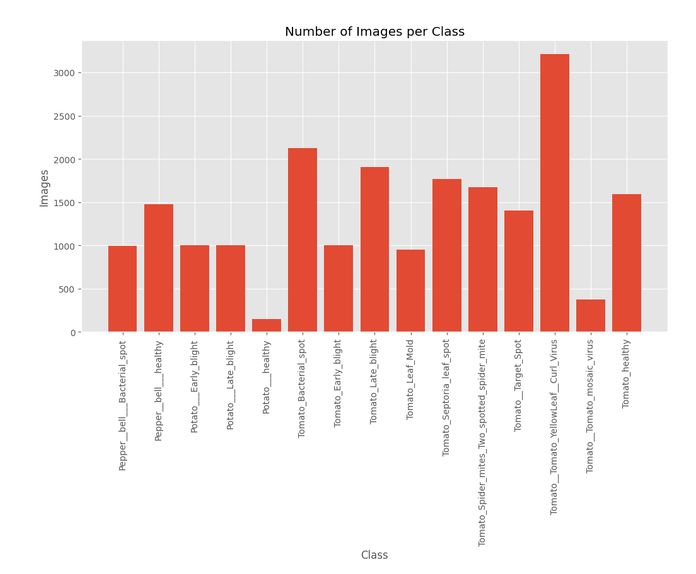

In [1]:
class_names = train_dataset.class_names

print(class_names)

NameError: name 'train_dataset' is not defined